In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.cluster as cluster
import umap
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import PPBuilder
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [2]:
def get_whole_seq(binder_idx):
    # Load the PDB file
    parser = PDBParser(QUIET=True)
    ppb= PPBuilder()
    pattern = f"../../data/sequences/{str(binder_idx)}_BAX_1F16_*.pdb"
    file = glob.glob(pattern)
    structure = parser.get_structure("protein", file[0])
    chains = ppb.build_peptides(structure)
    seq_prot = chains[0].get_sequence()
    seq_pept = chains[1].get_sequence()
    return seq_prot,seq_pept

In [3]:
df = pd.read_csv('../../data/mmpbsa/md_data_all_binders_raw.csv',index_col=0)

df.set_index('Binder_ID',inplace=True)
features  = ['energies','rmsd','bsa','hbond','sbridge']
n_clusters = 4
df['seq_prot'] =str
df['seq_pept'] =str
for idx in df.index:
    seq_prot, seq_pept = get_whole_seq(idx)
    df.loc[idx,'seq_prot'] = str(seq_prot)
    df.loc[idx,'seq_pept'] = str(seq_pept)
df_raw = df.copy()

In [4]:
# features which are already +1 as best value
for col in ['sbridge','hbond']:
    scaler = MinMaxScaler(feature_range=(-1,1))
    df[col] = scaler.fit_transform(df[[col]])
    
# features which need to be inverted so that best value is at +1
for col in ['energies','bsa','rmsd']:
    scaler = MinMaxScaler(feature_range=(-1,1))
    df[col] = - scaler.fit_transform(df[[col]])
    

In [5]:
df_raw

,sbridge,hbond,energies,bsa,rmsd,seq_prot,seq_pept
Binder_ID,,,,,,,
1,1.000000,2.977640,-60.670444,-1.599634,0.319568,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILAEVNK
2,1.000000,4.460748,-64.455556,0.021146,0.237327,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILEEVMK
3,1.000000,3.370119,-62.511111,-1.215878,0.231807,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILNEVMK
4,1.307685,3.951310,-61.568222,-1.774780,0.280639,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILEEVNK
5,1.000000,5.132062,-65.880444,-0.976195,0.282120,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGQEILKEVEK
...,...,...,...,...,...,...,...
98,1.000000,2.459585,-54.654444,-1.250439,0.342190,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTELMA
99,1.000000,2.238103,-58.685556,-0.979634,0.320138,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TVREMTEIMM
100,1.393881,3.403594,-59.273333,-0.932390,0.250268,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTRLMA


In [6]:
df

,sbridge,hbond,energies,bsa,rmsd,seq_prot,seq_pept
Binder_ID,,,,,,,
1,-0.166667,-0.447454,-0.640957,0.508246,0.304315,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILAEVNK
2,-0.166667,0.079516,-0.415057,-0.800392,0.637528,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILEEVMK
3,-0.166667,-0.308000,-0.531104,0.198397,0.659892,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILNEVMK
4,0.089738,-0.101495,-0.587377,0.649662,0.462041,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILEEVNK
5,-0.166667,0.318044,-0.330018,0.004874,0.456040,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGQEILKEVEK
...,...,...,...,...,...,...,...
98,-0.166667,-0.631526,-1.000000,0.226302,0.212657,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTELMA
99,-0.166667,-0.710222,-0.759418,0.007651,0.302004,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TVREMTEIMM
100,0.161568,-0.296106,-0.724339,-0.030495,0.585094,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTRLMA


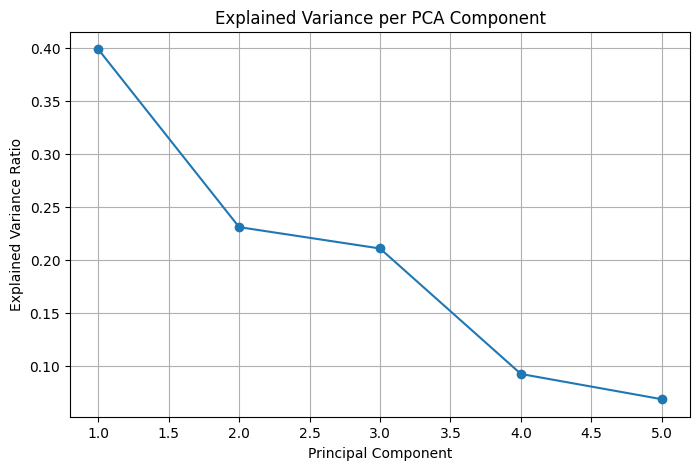

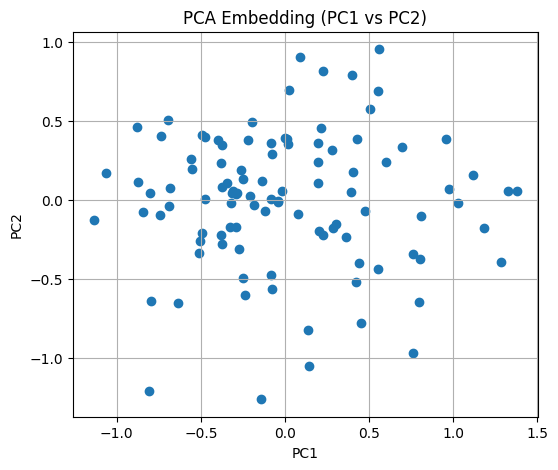


PCA Loadings:
               PC1       PC2       PC3       PC4       PC5
sbridge   0.385153  0.609174  0.685558  0.087047  0.054748
hbond     0.674611 -0.036796 -0.246595 -0.670305 -0.182834
energies  0.608825 -0.175571 -0.278611  0.721624  0.011901
bsa      -0.128708  0.771581 -0.620375  0.056824 -0.001790
rmsd      0.096562 -0.037296 -0.081926 -0.138360  0.981544

Top contributing feature per principal component:
PC1       hbond
PC2         bsa
PC3     sbridge
PC4    energies
PC5        rmsd
dtype: object


In [7]:

# -------------------------
# Assume df already exists
# -------------------------

# 1. Standardize the features
X = df[['sbridge','hbond','energies','bsa','rmsd']].values


# 2. Run PCA
pca = PCA(5)
X_pca = pca.fit_transform(X)

# 3. Explained variance per component
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per PCA Component")
plt.grid(True)
plt.show()

# 4. PCA embedding (PC1 vs PC2)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Embedding (PC1 vs PC2)")
plt.grid(True)
plt.show()

# 5. Get PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df[['sbridge','hbond','energies','bsa','rmsd']].columns
)

print("\nPCA Loadings:")
print(loadings)

# 6. Identify the dominant features per component
top_features = loadings.abs().idxmax()
print("\nTop contributing feature per principal component:")
print(top_features)

### three way split for testing

In [6]:
df_train = df_raw.sample(frac=0.6, random_state=42)
df_validation_test = df_raw.drop(df_train.index)
df_validation = df_validation_test.sample(frac=0.2, random_state=42)
df_test = df_validation_test.drop(df_validation.index)
df_split = {'train': df_train,"validation":df_validation,"test":df_test}

for idx in df_split.keys():
    
    # features which are already +1 as best value
    for col in ['sbridge','hbond']:
        scaler = MinMaxScaler(feature_range=(-1,1))
        df_split[idx][col] = scaler.fit_transform(df_split[idx][[col]])
        
    # features which need to be inverted so that best value is at +1
    for col in ['energies','bsa','rmsd']:
        scaler = MinMaxScaler(feature_range=(-1,1))
        df_split[idx][col] = - scaler.fit_transform(df_split[idx][[col]])
        
    df_split[idx]['final_score'] = df_split[idx]['energies'] * 1.5 + df_split[idx]['rmsd'] * 1.1 + df_split[idx]['bsa'] * 1.2 + df_split[idx]['hbond'] * 1.4 + df_split[idx]['sbridge'] * 1.3
    scaler = MinMaxScaler(feature_range=(-1,1))
    df_split[idx]['final_score'] = scaler.fit_transform(df_split[idx][['final_score']])
    df_split[idx][['final_score','seq_prot','seq_pept']].to_csv(f'../../data/mmpbsa/three_way_split/finished_data_cosine_sim_{idx}.csv')

### two way split for actual doing stuff

In [7]:
df_raw

,sbridge,hbond,energies,bsa,rmsd,seq_prot,seq_pept
Binder_ID,,,,,,,
1,1.000000,2.977640,-60.670444,-1.599634,0.319568,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILAEVNK
2,1.000000,4.460748,-64.455556,0.021146,0.237327,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILEEVMK
3,1.000000,3.370119,-62.511111,-1.215878,0.231807,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILNEVMK
4,1.307685,3.951310,-61.568222,-1.774780,0.280639,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILEEVNK
5,1.000000,5.132062,-65.880444,-0.976195,0.282120,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGQEILKEVEK
...,...,...,...,...,...,...,...
98,1.000000,2.459585,-54.654444,-1.250439,0.342190,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTELMA
99,1.000000,2.238103,-58.685556,-0.979634,0.320138,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TVREMTEIMM
100,1.393881,3.403594,-59.273333,-0.932390,0.250268,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTRLMA


In [9]:
df_raw['energy_bin'] = pd.cut(df_raw['energies'], bins=10)

In [13]:
from sklearn.model_selection import train_test_split

# Suppose `df` is your pandas DataFrame
# and `target` is the column whose distribution you want to preserve
X_train, X_validation = train_test_split(
    df_raw,
    test_size=0.3,
    random_state=42,
    stratify=df_raw['energy_bin']   # IMPORTANT
)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:

df[['final_score','seq_prot','seq_pept']].to_csv('../../data/mmpbsa/finished_data_cosine_sim.csv')

In [ ]:

n_features = len(features)
feature_colors = sns.color_palette("Set2", n_features)

fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 3 * 1), constrained_layout=True,sharex=True)

for i, idx_feat in enumerate(features):
        ax = axes[i]
        sns.kdeplot(df[idx_feat], ax=ax, color=feature_colors[i])
        

plt.tight_layout()
plt.show()

### own domain knowledge weighting

### classification idea - using minmax_scaled data

In [ ]:
kmeans_labels = cluster.KMeans(n_clusters=n_clusters,random_state=1).fit_predict(np.array(df[features ]))
embedding = umap.UMAP(random_state=1).fit_transform(np.array(df[features ]))

plt.figure(figsize=(15, 5))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], s=20, c=df['energies'].astype(float), cmap='Spectral')
plt.colorbar(scatter, label='energies')

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Embedding ')
plt.tight_layout()
plt.figure(figsize=(15, 5))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], s=20, c=kmeans_labels.astype(float), cmap='Spectral')
plt.colorbar(scatter, label='Labels')

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Embedding ')
plt.tight_layout()

In [ ]:
df['labels'] = kmeans_labels
# Calculate mean energies for each label
mean_energies = [df[df['labels'] == i]['energies'].mean() for i in range(5)]

# Create a mapping from old labels to new labels (sorted by mean energy)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted(range(5), key=lambda i: mean_energies[i]))}

# Apply the mapping to relabel
df['labels'] = df['labels'].map(label_mapping)
kmeans_labels = df['labels'].values

print('binder classes mean:')
print(f"no binder: {df[df['labels']== 0]['energies'].mean()}")
print(f"less worse binder:{df[df['labels']== 1]['energies'].mean()}")
print(f"mid binder:{df[df['labels']== 2]['energies'].mean()}")
print(f"semi good binder:{df[df['labels']== 3]['energies'].mean()}")
print(f"best binder:{df[df['labels']== 4]['energies'].mean()}")

In [ ]:

labels = sorted(df['labels'].unique())
n_labels = len(labels)
n_features = len(features)
feature_colors = sns.color_palette("Set2", n_features)

fig, axes = plt.subplots(n_labels, n_features, figsize=(4 * n_features, 3 * n_labels), constrained_layout=True,sharex=True)

for i, lab in enumerate(labels):
    subset = df[df['labels'] == lab]
    for j, feat in enumerate(features):
        ax = axes[i, j]
        sns.kdeplot(subset[feat], ax=ax, color=feature_colors[j])
        if j == 0:
            ax.set_ylabel(f"Label {lab}\n(n={len(subset)})")
        else:
            ax.set_ylabel('')
        if i == n_labels - 1:
            ax.set_xlabel(feat)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:

labels = sorted(df['labels'].unique())
n_features = len(features)

fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4), constrained_layout=False)

for j, feat in enumerate(features):
    ax = axes[j]
    for lab in labels:
        subset = df[df['labels'] == lab]
        sns.kdeplot(subset[feat], ax=ax, label=f"Label {lab}")
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

# Place a wide legend below the figure
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.2)
fig.legend(handles, legend_labels, loc='lower center', ncol=len(labels), title='Label', frameon=False)

plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

# Prepare features (X) and target (y)
X = df[features]
Y= df['labels']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X,Y)

print(f'features: {features}')
print("Linear Regression Model:")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {model.score(X, Y)}")

In [ ]:
model.intercept_ + (X * model.coef_).sum(axis=1)

In [ ]:
df['final_score'] = model.intercept_ + (X * model.coef_).sum(axis=1)
df.index = df.index.astype(str)

In [ ]:
df

### regression idea with pca

In [ ]:
# Prepare features (X) and target (y)
X = df[['energies','rmsd','bsa','hbond','sbridge']]
Y= df['labels']

# Hold out a certain percentile of each label for testing
test_percentile = 20  # Hold out 20% for testing

X_train, X_test = [], []
Y_train, Y_test = [], []

for label in df['labels'].unique():
    label_mask = df['labels'] == label
    label_indices = df[label_mask].index
    
    n_test = max(1, int(len(label_indices) * test_percentile / 100))
    test_indices = np.random.choice(label_indices, size=n_test, replace=False)
    train_indices = label_indices.difference(test_indices)
    
    X_train.append(X.loc[train_indices])
    X_test.append(X.loc[test_indices])
    Y_train.append(Y.loc[train_indices])
    Y_test.append(Y.loc[test_indices])

X_train = pd.concat(X_train)
X_test = pd.concat(X_test)
Y_train = pd.concat(Y_train)
Y_test = pd.concat(Y_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set label distribution:\n{Y_train.value_counts().sort_index()}")
print(f"\nTest set label distribution:\n{Y_test.value_counts().sort_index()}")


# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train,Y_train)
pred_Y = model.predict(X_test)



print("Linear Regression Model:")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {model.score(X_test, Y_test)}")

In [ ]:
# -------------------------
# Assume df already exists
# -------------------------

# 1. Standardize the features
X = df[['sbridge', 'hbond', 'energies', 'bsa', 'rmsd']]

# 2. Run PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# 3. Explained variance per component
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per PCA Component")
plt.grid(True)
plt.show()

#4. PCA embedding (PC1 vs PC2)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Embedding (PC1 vs PC2)")
plt.grid(True)
plt.show()

# 5. Get PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index= df.columns[:-1]
)

print("\nPCA Loadings:")
print(loadings)

# 6. Identify the dominant features per component
top_features = loadings.abs().idxmax()
print("\nTop contributing feature per principal component:")
print(top_features)

In [ ]:
pca.components[0]